Data Source: https://www.kaggle.com/datasets/jackdaoud/marketing-data/data

In [1]:
#Step 1: Import Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Step 2: Import Data
dt = pd.read_csv('./ifood_df.csv')
print(dt.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Income                2205 non-null   int64
 1   Kidhome               2205 non-null   int64
 2   Teenhome              2205 non-null   int64
 3   Recency               2205 non-null   int64
 4   MntWines              2205 non-null   int64
 5   MntFruits             2205 non-null   int64
 6   MntMeatProducts       2205 non-null   int64
 7   MntFishProducts       2205 non-null   int64
 8   MntSweetProducts      2205 non-null   int64
 9   MntGoldProds          2205 non-null   int64
 10  NumDealsPurchases     2205 non-null   int64
 11  NumWebPurchases       2205 non-null   int64
 12  NumCatalogPurchases   2205 non-null   int64
 13  NumStorePurchases     2205 non-null   int64
 14  NumWebVisitsMonth     2205 non-null   int64
 15  AcceptedCmp3          2205 non-null   int64
 16  Accept

In [3]:
print (dt.head(10))

   Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0   58138        0         0       58       635         88              546   
1   46344        1         1       38        11          1                6   
2   71613        0         0       26       426         49              127   
3   26646        1         0       26        11          4               20   
4   58293        1         0       94       173         43              118   
5   62513        0         1       16       520         42               98   
6   55635        0         1       34       235         65              164   
7   33454        1         0       32        76         10               56   
8   30351        1         0       19        14          0               24   
9    5648        1         1       68        28          0                6   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  .

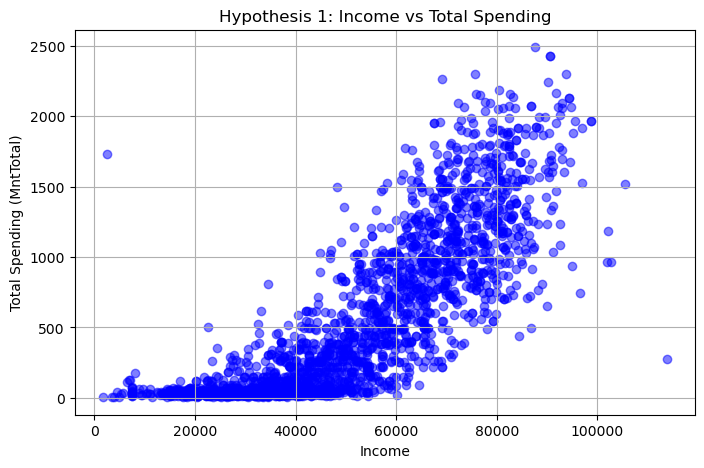

In [4]:
# Step 3: Hypothesis 1:
# Higher-income customers spend more money overall (MntTotal).


plt.figure(figsize=(8,5))
plt.scatter(dt["Income"], dt["MntTotal"], alpha=0.5, color="blue")
plt.title("Hypothesis 1: Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending (MntTotal)")
plt.grid(True)
plt.show()


In [5]:
corr_income_spending = dt["Income"].corr(dt["MntTotal"])
print(f"Correlation between Income and Spending: {corr_income_spending:.2f}")

Correlation between Income and Spending: 0.82


In [16]:
print(f"Income vs Spending correlation: {corr_income_spending:.2f} is strong positive. Thus, Hypothesis confirmed")

Income vs Spending correlation: 0.82 is strong positive. Thus, Hypothesis confirmed



Average Spending by Family Type:
 HasChildren
No     1041.207006
Yes     372.237159
Name: MntTotal, dtype: float64


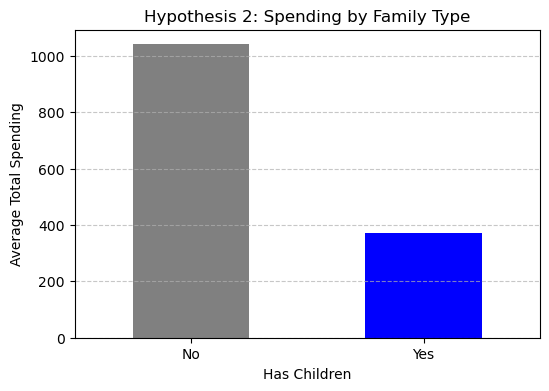

In [21]:
# Step 4: Hypothesis 2
# "Customers with children spend less than those without children."
# -----------------------------------------------------

# Create new column to identify the with child or without child
dt["HasChildren"] = np.where(dt["Kidhome"] + dt["Teenhome"] > 0, "Yes", "No")

# Compute average spending per group
avg_spending_children = dt.groupby("HasChildren")["MntTotal"].mean()
print("\nAverage Spending by Family Type:\n", avg_spending_children)

# Bar chart visualization
plt.figure(figsize=(6,4))
avg_spending_children.plot(kind="bar", color=["gray", "blue"])
plt.title("Hypothesis 2: Spending by Family Type")
plt.ylabel("Average Total Spending")
plt.xlabel("Has Children")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [18]:
print(f"Families spend less (${avg_spending_children['Yes']:.0f}) vs Child-free (${avg_spending_children['No']:.0f}) . Thus, Hypothesis confirmed")

Families spend less ($372) vs Child-free ($1041) . Thus, Hypothesis confirmed



Average Spending by Campaign Response:
 Response
0    498.433761
1    924.408408
Name: MntTotal, dtype: float64


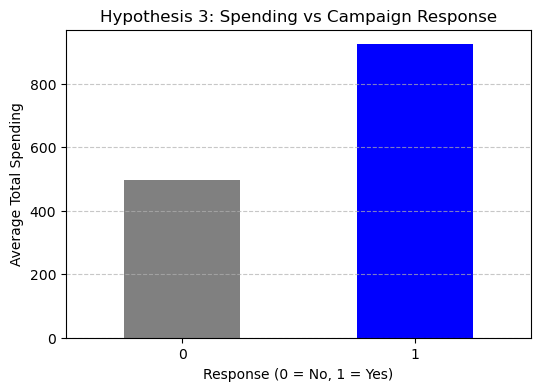

In [19]:
# Step 5: Hypothesis 3
# "Customers who spend more are more likely to respond to campaigns."
# -----------------------------------------------------

avg_spending_response = dt.groupby("Response")["MntTotal"].mean()
print("\nAverage Spending by Campaign Response:\n", avg_spending_response)

# Bar chart
plt.figure(figsize=(6,4))
avg_spending_response.plot(kind="bar", color=["gray","blue"])
plt.title("Hypothesis 3: Spending vs Campaign Response")
plt.ylabel("Average Total Spending")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [20]:

print(f"Responders spend more (${avg_spending_response[1]:.0f}) vs Non-responders (${avg_spending_response[0]:.0f}) . Thus, Hypothesis confirmed")

Responders spend more ($924) vs Non-responders ($498) . Thus, Hypothesis confirmed
